# StePS PDS Snapshot Explorer

Explore N-body snapshots from a **Poincaré Dodecahedral Space** (S³/I\*) StePS run.
Particles live on the 3-sphere S³; their Cartesian positions in the output files are
the stereographic projections of the underlying unit quaternions.

**Kernel:** `stepsic` conda environment  
**Output directory:** `/v/scratch/astro/dodeca/`

> **Note on data quality:** if any snapshot shows `N_valid = 0` in the inventory table,
> the simulation diverged to NaN — check the StePS PDS integration (PDS_Q must be
> re-derived from x[] after every drift step, and boundary wrapping applied).
> All plots handle NaN positions gracefully and will still render once valid data exists.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import h5py
import pandas as pd

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.labelsize': 12, 'axes.titlesize': 12})

# ── Configuration ──────────────────────────────────────────────────────────
SNAP_DIR = Path('/v/scratch/astro/dodeca/')

snap_files = sorted(SNAP_DIR.glob('snapshot_*.hdf5'))
print(f'Found {len(snap_files)} snapshots in {SNAP_DIR}')
for s in snap_files:
    print(f'  {s.name}')

Found 5 snapshots in /v/scratch/astro/dodeca
  snapshot_0000.hdf5
  snapshot_0001.hdf5
  snapshot_0002.hdf5
  snapshot_0003.hdf5
  snapshot_0004.hdf5


In [2]:
# ── Helper functions ───────────────────────────────────────────────────────

def read_header(fname):
    with h5py.File(fname, 'r') as f:
        hdr = {k: v for k, v in f['Header'].attrs.items()}
    return {k: (v.decode() if isinstance(v, bytes) else v) for k, v in hdr.items()}


def load_snapshot(fname, filter_nan=True):
    """Load a StePS HDF5 snapshot.  NaN particles are removed when filter_nan=True."""
    with h5py.File(fname, 'r') as f:
        pos  = f['PartType1/Coordinates'][:]
        vel  = f['PartType1/Velocities'][:]
        mass = f['PartType1/Masses'][:]
        ids  = f['PartType1/ParticleIDs'][:]
        hdr  = {k: v for k, v in f['Header'].attrs.items()}
    hdr = {k: (v.decode() if isinstance(v, bytes) else v) for k, v in hdr.items()}
    n_total = len(pos)
    n_nan   = int(np.isnan(pos).any(axis=1).sum())
    if n_nan > 0:
        print(f'  WARNING: {n_nan}/{n_total} particles have NaN positions '
              f'in {Path(fname).name} — simulation diverged!')
    if filter_nan and n_nan > 0:
        ok   = np.isfinite(pos).all(axis=1)
        pos  = pos[ok]; vel = vel[ok]; mass = mass[ok]; ids = ids[ok]
    return dict(pos=pos, vel=vel, mass=mass, ids=ids, hdr=hdr,
                n_total=n_total, n_nan=n_nan)


def cart_to_quat(pos, R_curv):
    """Inverse stereographic projection: Cartesian R^3 -> S^3 unit quaternions.
    q = (R^2-r^2, 2Rx, 2Ry, 2Rz) / (R^2+r^2)
    """
    r2 = np.einsum('ij,ij->i', pos, pos)
    d  = R_curv**2 + r2
    return np.stack([(R_curv**2 - r2) / d,
                     2*R_curv*pos[:, 0]/d,
                     2*R_curv*pos[:, 1]/d,
                     2*R_curv*pos[:, 2]/d], axis=1)


def pairwise_chi(quats):
    """All pairwise geodesic distances chi_ij = arccos(q_i . q_j) in radians."""
    dots = np.clip(quats @ quats.T, -1.0, 1.0)
    return np.arccos(dots[np.triu_indices(len(quats), k=1)])


def load_logfile(path):
    """Parse StePS logfile; deduplicate MPI-repeated rows."""
    cols, rows, seen = None, [], set()
    with open(path) as fh:
        for line in fh:
            if line.startswith('#'):
                s = line[1:].strip()
                if '\t' in s and s[0].isupper():
                    cols = [c.strip() for c in s.split('\t')]
            else:
                vals = line.strip().split()
                if vals:
                    key = tuple(vals)
                    if key not in seen:
                        seen.add(key); rows.append([float(v) for v in vals])
    if cols is None:
        cols = [f'col_{i}' for i in range(len(rows[0]))]
    return pd.DataFrame(rows, columns=cols)


def warn_plot(ax, message):
    """Show a warning message inside an axes when no valid data is available."""
    ax.text(0.5, 0.5, message, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='red',
            bbox=dict(boxstyle='round', facecolor='#fff0f0', alpha=0.8))
    ax.set_axis_off()


print('Helper functions defined.')

Helper functions defined.


## 1. Snapshot Inventory

In [3]:
rows = []
for s in snap_files:
    with h5py.File(s, 'r') as f:
        pos = f['PartType1/Coordinates'][:]
        hdr = {k: v for k, v in f['Header'].attrs.items()}
        hdr = {k: (v.decode() if isinstance(v, bytes) else v) for k, v in hdr.items()}
    n_valid = int(np.isfinite(pos).all(axis=1).sum())
    n_total = len(pos)
    rows.append({
        'File'         : s.name,
        'z'            : round(float(hdr.get('Redshift', 0)), 3),
        'a'            : round(float(hdr.get('Time', 0)), 5),
        'N_total'      : n_total,
        'N_valid'      : n_valid,
        'R_curv [Mpc]' : hdr.get('R_curvature_Mpc', ''),
        'R_sim [Mpc]'  : hdr.get('SimulationRadius', ''),
        'Topology'     : hdr.get('TopologicalManifold', ''),
        'Size [kB]'    : s.stat().st_size // 1024,
    })

df = pd.DataFrame(rows).set_index('File')
# Highlight rows with NaN particles
def highlight_nan(row):
    color = 'background-color: #ffe0e0' if row.N_valid < row.N_total else ''
    return [color] * len(row)

df.style.apply(highlight_nan, axis=1)

,z,a,N_total,N_valid,R_curv [Mpc],R_sim [Mpc],Topology,Size [kB]
File,,,,,,,,
snapshot_0000.hdf5,14.984000,0.062560,1000,1000,3100.000000,960.000000,S^3/I*,67
snapshot_0001.hdf5,2.971000,0.251810,1000,1000,3100.000000,960.000000,S^3/I*,67
snapshot_0002.hdf5,0.999000,0.500130,1000,1000,3100.000000,960.000000,S^3/I*,67
snapshot_0003.hdf5,0.498000,0.667420,1000,1000,3100.000000,960.000000,S^3/I*,67
snapshot_0004.hdf5,-0.000000,1.000250,1000,1000,3100.000000,960.000000,S^3/I*,67


## 2. Simulation Diagnostics (Logfile)

The logfile records the expansion history and integration diagnostics at every timestep.
Each row is written once per MPI rank; the loader deduplicates them automatically.

In [4]:
log = load_logfile(SNAP_DIR / 'Logfile.dat')
print(f'Logfile: {len(log)} unique timesteps, {len(log.columns)} columns')
print('Columns:', list(log.columns))
log.head(3)

Logfile: 517 unique timesteps, 8 columns
Columns: ['Time[Gy]', 'Max_Error', 'Step_Size[Gy]', 'Scale factor', 'Redshift', 'Hubble_Parameter[km/s/Mpc]', 'Deceleration_Parameter', 'Omega_m_Effective']


,Time[Gy],Max_Error,Step_Size[Gy],Scale factor,Redshift,Hubble_Parameter[km/s/Mpc],Deceleration_Parameter,Omega_m_Effective
0,0.095862,128342700.0,0.000442,0.031346,30.901668,6800.124941,0.499898,0.999932
1,0.096279,122208100.0,0.000416,0.031437,30.809666,6770.731673,0.499897,0.999931
2,0.096705,113168800.0,0.000426,0.031530,30.716069,6740.872186,0.499896,0.999931


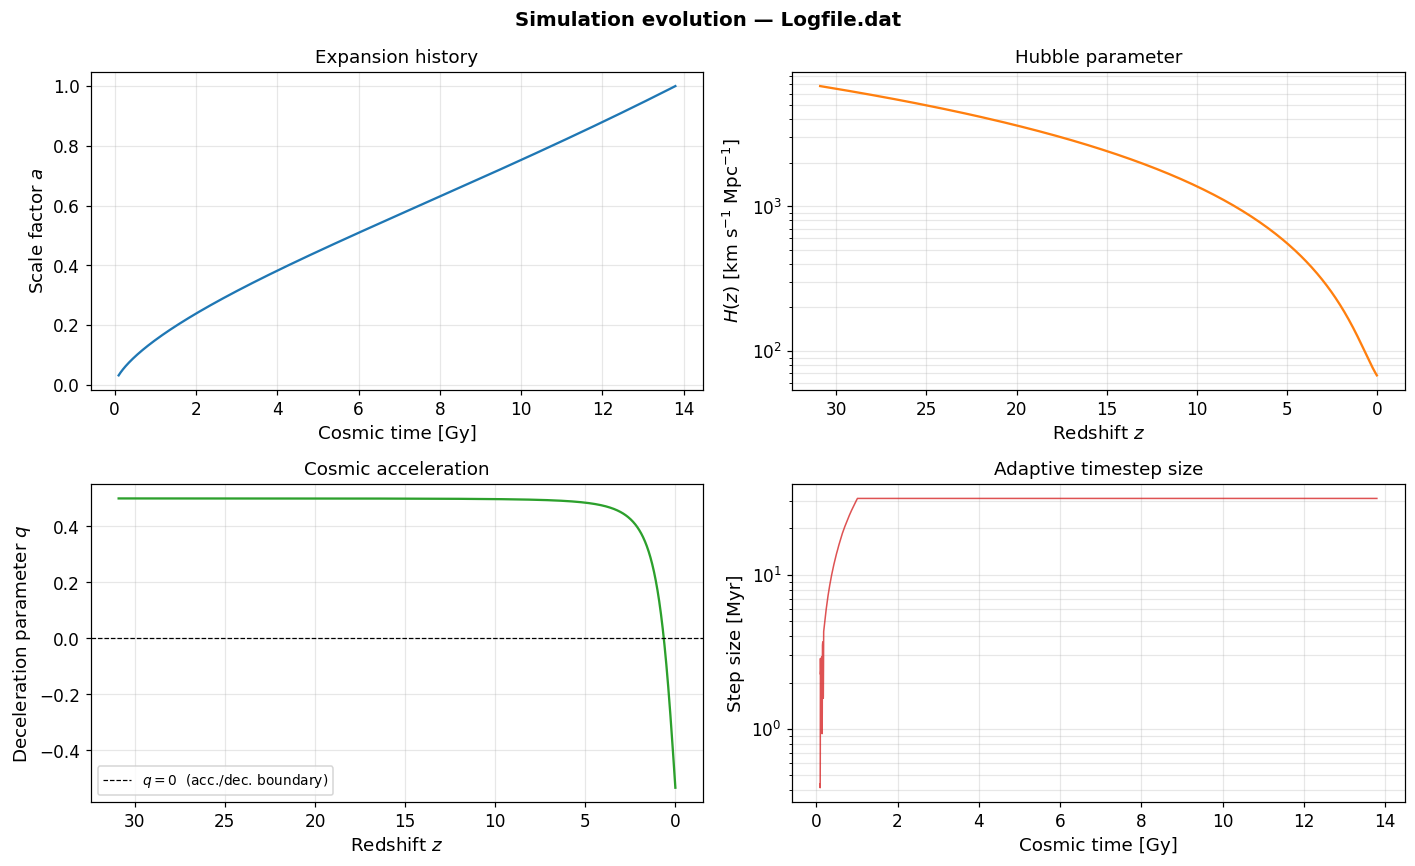

In [5]:
# Column index map (auto-detect by name if possible, fall back to index)
def col(df, name, fallback_idx):
    for c in df.columns:
        if name.lower() in c.lower():
            return df[c].values
    return df.iloc[:, fallback_idx].values

t  = col(log, 'Time',          0)
a  = col(log, 'Scale',         3)
z  = col(log, 'Redshift',      4)
H  = col(log, 'Hubble',        5)
q  = col(log, 'Deceleration',  6)
dt = col(log, 'Step',          2)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Simulation evolution — Logfile.dat', fontsize=13, fontweight='bold')

ax = axes[0, 0]
ax.plot(t, a, 'C0-', lw=1.5)
ax.set_xlabel('Cosmic time [Gy]');  ax.set_ylabel('Scale factor $a$')
ax.set_title('Expansion history');  ax.grid(alpha=0.3)

ax = axes[0, 1]
mask = z > 0
ax.semilogy(z[mask], H[mask], 'C1-', lw=1.5)
ax.set_xlabel('Redshift $z$');  ax.set_ylabel('$H(z)$ [km s$^{-1}$ Mpc$^{-1}$]')
ax.set_title('Hubble parameter');  ax.invert_xaxis();  ax.grid(alpha=0.3, which='both')

ax = axes[1, 0]
ax.plot(z, q, 'C2-', lw=1.5)
ax.axhline(0, c='k', ls='--', lw=0.8, label='$q=0$  (acc./dec. boundary)')
ax.set_xlabel('Redshift $z$');  ax.set_ylabel('Deceleration parameter $q$')
ax.set_title('Cosmic acceleration');  ax.invert_xaxis()
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.semilogy(t, dt * 1e3, 'C3-', lw=1.0, alpha=0.8)
ax.set_xlabel('Cosmic time [Gy]');  ax.set_ylabel('Step size [Myr]')
ax.set_title('Adaptive timestep size');  ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 3. Snapshot Explorer

Change `SNAP_IDX` (0 = earliest, -1 = latest) and re-run the cells below.

In [6]:
# ── Change this index to switch between snapshots ────────────────────────
SNAP_IDX = -1
# ─────────────────────────────────────────────────────────────────────────

data   = load_snapshot(snap_files[SNAP_IDX])
hdr    = data['hdr']
pos    = data['pos']         # valid (non-NaN) particles only
vel    = data['vel']
R_curv = float(hdr['R_curvature_Mpc'])
R_sim  = float(hdr['SimulationRadius'])
z_snap = float(hdr['Redshift'])
a_snap = float(hdr['Time'])
N_ok   = len(pos)

print(f'  File     : {snap_files[SNAP_IDX].name}')
print(f'  Redshift : z = {z_snap:.4f}   (a = {a_snap:.5f})')
print(f'  Valid N  : {N_ok} / {data["n_total"]} particles')
print(f'  R_curv   : {R_curv:.0f} Mpc   R_sim : {R_sim:.0f} Mpc')
print(f'  Topology : {hdr.get("TopologicalManifold", "unknown")}')

  File     : snapshot_0004.hdf5
  Redshift : z = -0.0002   (a = 1.00025)
  Valid N  : 1000 / 1000 particles
  R_curv   : 3100 Mpc   R_sim : 960 Mpc
  Topology : S^3/I*


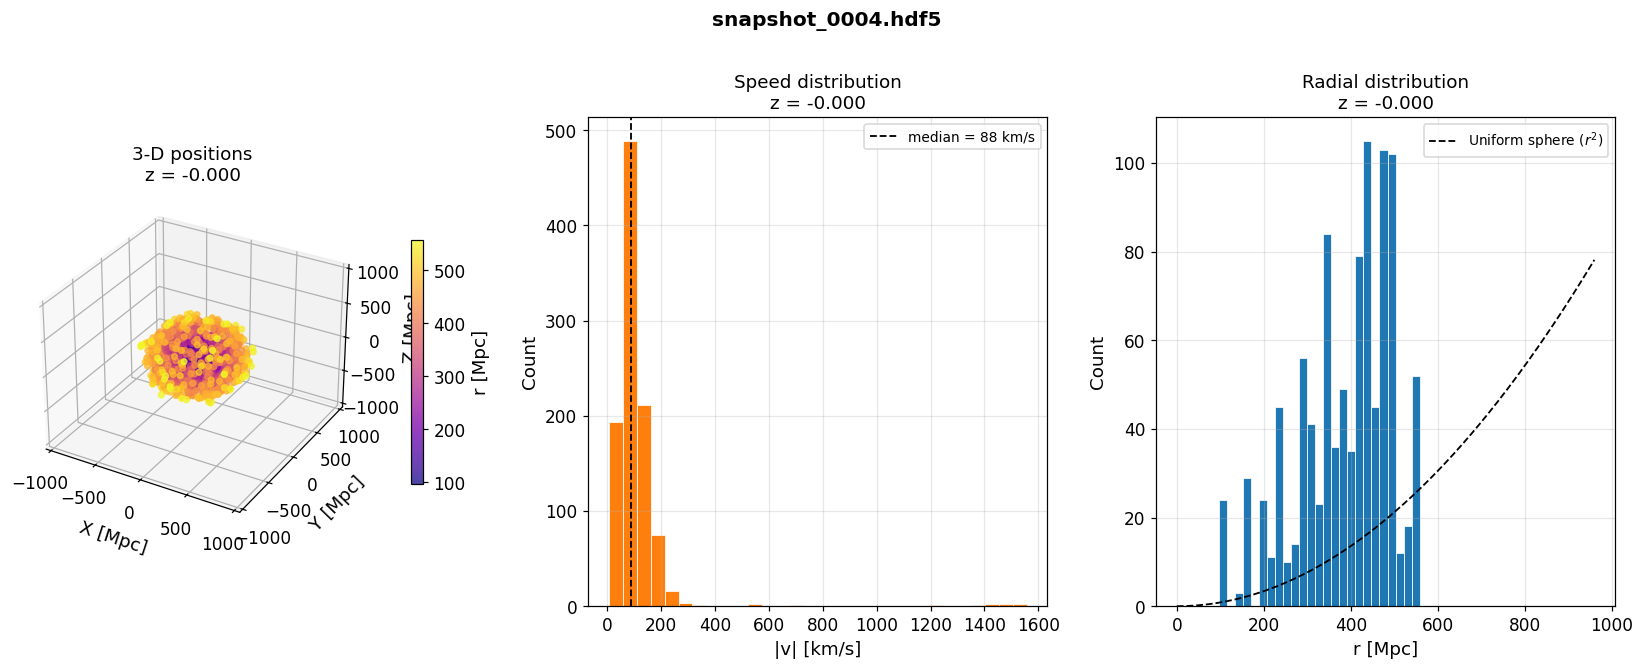

In [7]:
if N_ok == 0:
    print('No valid particles to plot — all positions are NaN.')
    print('The simulation diverged.  Check the StePS PDS step.cc integration.')
else:
    r = np.linalg.norm(pos, axis=1)
    v = np.linalg.norm(vel, axis=1)

    fig = plt.figure(figsize=(15, 6))

    ax3 = fig.add_subplot(1, 3, 1, projection='3d')
    sc  = ax3.scatter(*pos.T, c=r, cmap='plasma', s=14, alpha=0.75)
    ax3.set_xlabel('X [Mpc]', labelpad=6)
    ax3.set_ylabel('Y [Mpc]', labelpad=6)
    ax3.set_zlabel('Z [Mpc]', labelpad=6)
    ax3.set_title(f'3-D positions\nz = {z_snap:.3f}')
    lim = R_sim * 1.1
    ax3.set_xlim(-lim, lim); ax3.set_ylim(-lim, lim); ax3.set_zlim(-lim, lim)
    fig.colorbar(sc, ax=ax3, label='r [Mpc]', shrink=0.5, pad=0.1)

    ax = fig.add_subplot(1, 3, 2)
    ax.hist(v, bins=30, color='C1', edgecolor='white', lw=0.5)
    ax.axvline(np.median(v), c='k', ls='--', lw=1.2,
               label=f'median = {np.median(v):.0f} km/s')
    ax.set_xlabel('|v| [km/s]');  ax.set_ylabel('Count')
    ax.set_title(f'Speed distribution\nz = {z_snap:.3f}')
    ax.legend(fontsize=9);  ax.grid(alpha=0.3)

    ax = fig.add_subplot(1, 3, 3)
    ax.hist(r, bins=25, color='C0', edgecolor='white', lw=0.5)
    r_ref = np.linspace(0, R_sim, 200)
    ax.plot(r_ref, N_ok/(R_sim/25) * (r_ref/R_sim)**2 * 3,
            'k--', lw=1.2, label='Uniform sphere ($r^2$)')
    ax.set_xlabel('r [Mpc]');  ax.set_ylabel('Count')
    ax.set_title(f'Radial distribution\nz = {z_snap:.3f}')
    ax.legend(fontsize=9);  ax.grid(alpha=0.3)

    fig.suptitle(snap_files[SNAP_IDX].name, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_257574/1720233324.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


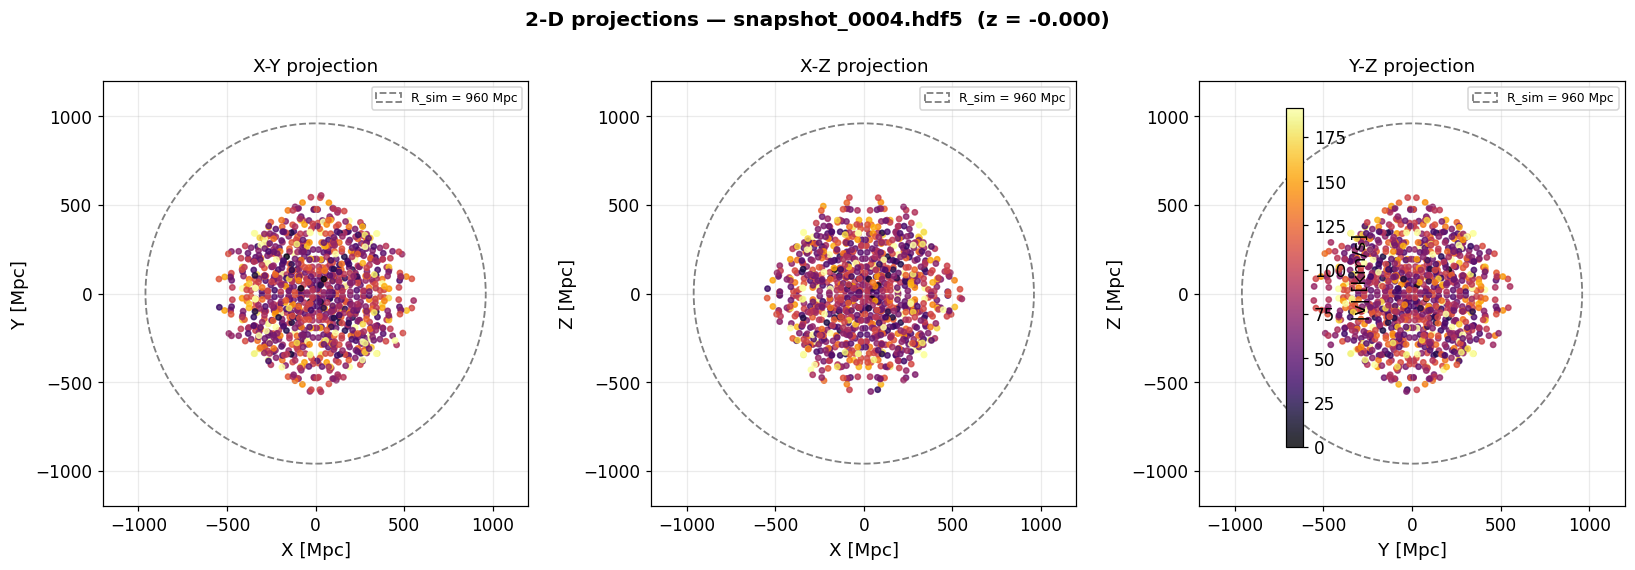

In [8]:
if N_ok == 0:
    print('Skipping 2D projections — no valid particle data.')
else:
    r = np.linalg.norm(pos, axis=1)
    v = np.linalg.norm(vel, axis=1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    proj = [('X', 'Y', 0, 1), ('X', 'Z', 0, 2), ('Y', 'Z', 1, 2)]
    for ax, (xl, yl, xi, yi) in zip(axes, proj):
        sc = ax.scatter(pos[:, xi], pos[:, yi], c=v, cmap='inferno', s=12,
                        alpha=0.8, vmin=0, vmax=np.percentile(v, 95))
        circ = plt.Circle((0, 0), R_sim, fill=False, color='grey',
                           ls='--', lw=1.2, label=f'R_sim = {R_sim:.0f} Mpc')
        ax.add_patch(circ)
        ax.set_xlim(-R_sim*1.25, R_sim*1.25);  ax.set_ylim(-R_sim*1.25, R_sim*1.25)
        ax.set_xlabel(f'{xl} [Mpc]');  ax.set_ylabel(f'{yl} [Mpc]')
        ax.set_title(f'{xl}-{yl} projection');  ax.set_aspect('equal')
        ax.grid(alpha=0.25);  ax.legend(fontsize=8)
    fig.colorbar(sc, ax=axes, label='|v| [km/s]', shrink=0.8, pad=0.02)
    fig.suptitle(f'2-D projections — {snap_files[SNAP_IDX].name}  (z = {z_snap:.3f})',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Multi-Snapshot Evolution

All available snapshots shown side-by-side (X-Y plane, coloured by radial distance).
Red hatching = snapshot has NaN positions (simulation diverged).

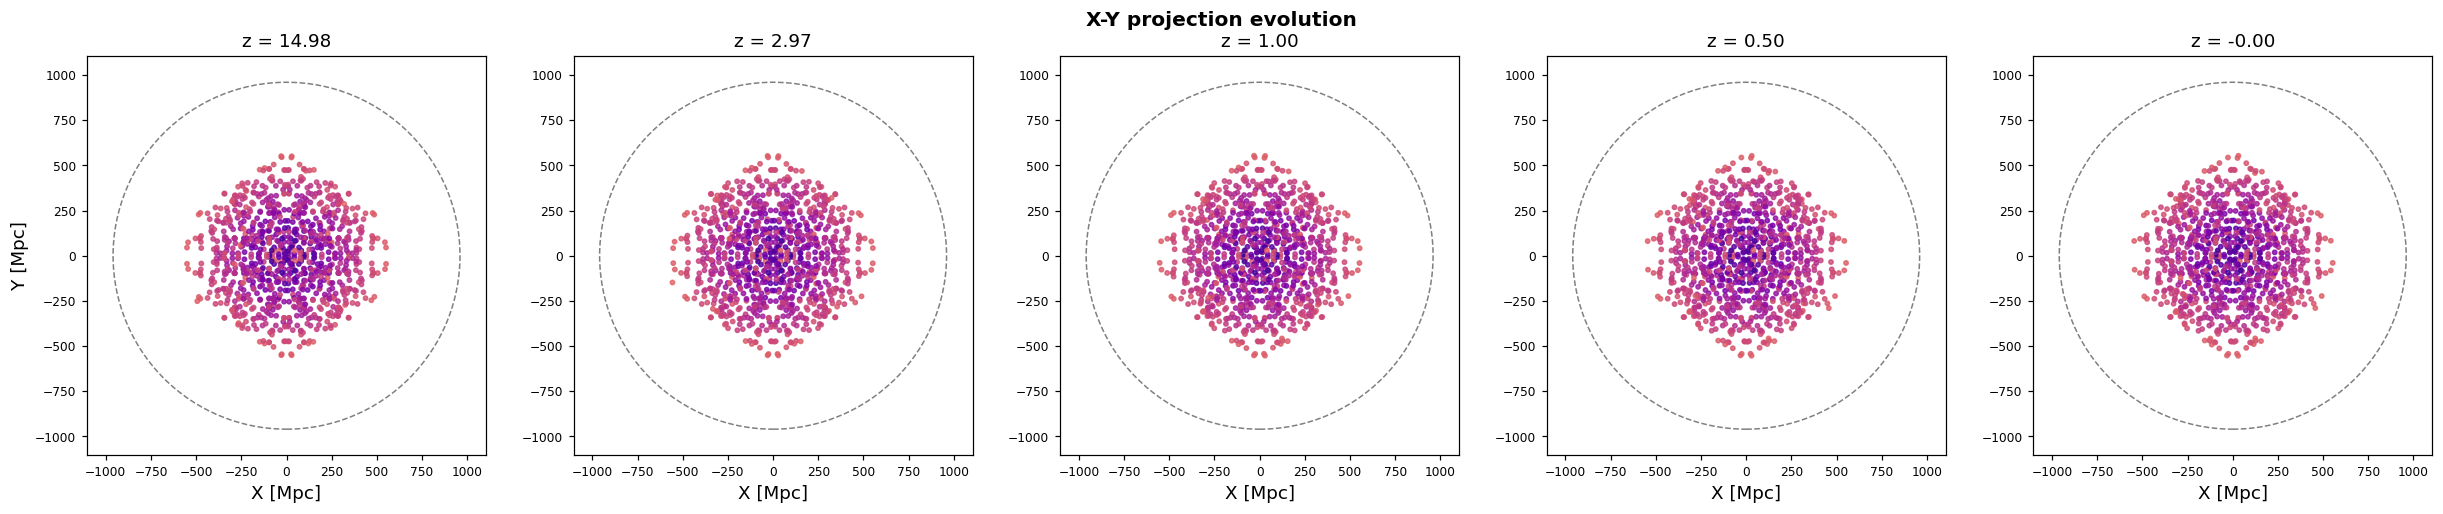

In [9]:
n = len(snap_files)
fig, axes = plt.subplots(1, n, figsize=(4.5*n, 4.5))
if n == 1: axes = [axes]

for ax, sf in zip(axes, snap_files):
    d   = load_snapshot(sf)
    p   = d['pos'];   z_l = float(d['hdr']['Redshift']);   Rs = float(d['hdr']['SimulationRadius'])
    ax.add_patch(plt.Circle((0, 0), Rs, fill=False, color='grey', ls='--', lw=1))
    ax.set_xlim(-Rs*1.15, Rs*1.15);  ax.set_ylim(-Rs*1.15, Rs*1.15)
    ax.set_aspect('equal');  ax.set_title(f'z = {z_l:.2f}');  ax.set_xlabel('X [Mpc]')
    if ax is axes[0]: ax.set_ylabel('Y [Mpc]')
    if len(p) == 0:
        ax.text(0.5, 0.5, 'NaN\n(sim diverged)', transform=ax.transAxes,
                ha='center', va='center', color='red', fontsize=10)
        ax.set_facecolor('#fff8f8')
    else:
        r_l = np.linalg.norm(p, axis=1)
        sc  = ax.scatter(p[:, 0], p[:, 1], c=r_l, cmap='plasma', s=8, alpha=0.8, vmin=0, vmax=Rs)
    ax.tick_params(labelsize=8)

fig.suptitle('X-Y projection evolution', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Radial Density Profile

Number density $\\rho(r)$ in spherical shells at each output epoch.
Snapshots with all-NaN positions are skipped.

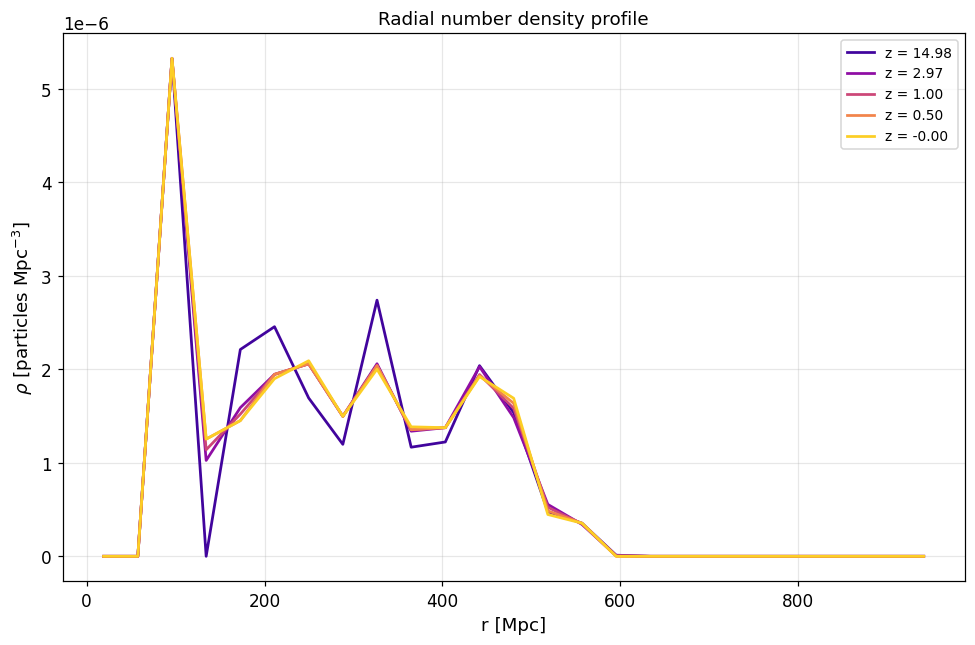

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_files)))
plotted = 0

for sf, col in zip(snap_files, colors):
    d   = load_snapshot(sf)
    p   = d['pos']
    if len(p) == 0:
        continue
    z_l = float(d['hdr']['Redshift'])
    Rs  = float(d['hdr']['SimulationRadius'])
    r_l = np.linalg.norm(p, axis=1)
    bins = np.linspace(0, Rs, 26)
    cnt, edges = np.histogram(r_l, bins=bins)
    rmid = 0.5 * (edges[:-1] + edges[1:])
    vol  = 4/3 * np.pi * (edges[1:]**3 - edges[:-1]**3)
    ax.plot(rmid, cnt / vol, color=col, lw=1.8, label=f'z = {z_l:.2f}')
    plotted += 1

if plotted == 0:
    warn_plot(ax, 'No valid snapshots\n(all positions are NaN)')
else:
    ax.set_xlabel('r [Mpc]')
    ax.set_ylabel(r'$\rho$ [particles Mpc$^{-3}$]')
    ax.set_title('Radial number density profile')
    ax.legend(fontsize=9);  ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. S³ Analysis — Geodesic Coordinates

Particle positions are converted to **unit quaternions** via the inverse stereographic map:
$$q = \\frac{(R^2 - r^2,\ 2Rx,\ 2Ry,\ 2Rz)}{R^2 + r^2}$$
The **geodesic distance from the fundamental-domain centre** (north pole $e_0 = (1,0,0,0)$)
is $\\chi = \\arccos(q_0)$.  For a uniform Poisson process on S³, the pdf is
$p(\\chi) \\propto \\sin^2\\chi$.

Quaternion norm: mean = 1.00000000,  std = 1.11e-16  (should be 1.0)


/tmp/ipykernel_257574/226202119.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_r  /= np.trapz(p_r, chi_r)


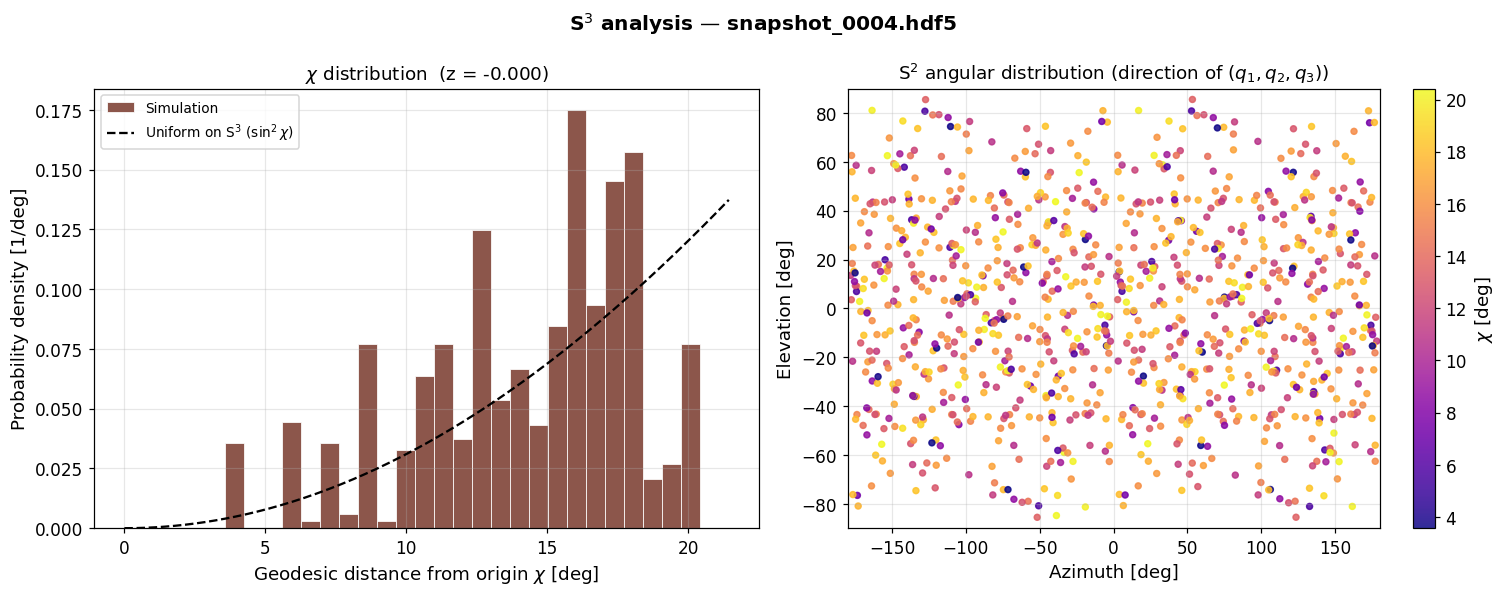

In [11]:
if N_ok == 0:
    print('No valid particles — skipping S3 analysis.')
else:
    quats = cart_to_quat(pos, R_curv)
    norms = np.linalg.norm(quats, axis=1)
    print(f'Quaternion norm: mean = {norms.mean():.8f},  std = {norms.std():.2e}  (should be 1.0)')

    chi     = np.arccos(np.clip(quats[:, 0], -1.0, 1.0))
    chi_deg = np.degrees(chi)

    q_xyz  = quats[:, 1:]
    q_norm = np.linalg.norm(q_xyz, axis=1, keepdims=True)
    q_hat  = np.where(q_norm > 1e-12, q_xyz / q_norm, q_xyz)
    az = np.degrees(np.arctan2(q_hat[:, 1], q_hat[:, 0]))
    el = np.degrees(np.arcsin(np.clip(q_hat[:, 2], -1, 1)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    ax = axes[0]
    ax.hist(chi_deg, bins=25, density=True, color='C5', edgecolor='white', lw=0.5,
            label='Simulation')
    chi_r = np.linspace(0, max(chi_deg)*1.05, 300)
    p_r   = np.sin(np.radians(chi_r))**2
    p_r  /= np.trapz(p_r, chi_r)
    ax.plot(chi_r, p_r, 'k--', lw=1.5, label='Uniform on S$^3$ ($\\sin^2\\chi$)')
    ax.set_xlabel(r'Geodesic distance from origin $\chi$ [deg]')
    ax.set_ylabel('Probability density [1/deg]')
    ax.set_title(f'$\\chi$ distribution  (z = {z_snap:.3f})')
    ax.legend(fontsize=9);  ax.grid(alpha=0.3)

    ax = axes[1]
    sc = ax.scatter(az, el, c=chi_deg, cmap='plasma', s=15, alpha=0.85)
    fig.colorbar(sc, ax=ax, label=r'$\chi$ [deg]')
    ax.set_xlabel('Azimuth [deg]');  ax.set_ylabel('Elevation [deg]')
    ax.set_title('S$^2$ angular distribution (direction of $(q_1,q_2,q_3)$)')
    ax.grid(alpha=0.3);  ax.set_xlim(-180, 180);  ax.set_ylim(-90, 90)

    fig.suptitle(f'S$^3$ analysis — {snap_files[SNAP_IDX].name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7. Pairwise Geodesic Distances

The histogram of all N(N-1)/2 pairwise geodesic separations $\\chi_{ij}$ on S³.
Clustering growth shows as an excess at small $\\chi$ vs. the uniform reference
$p(\\chi) \\propto \\sin^2\\chi$.

Computing pairwise geodesic distances for all valid snapshots...
  z = 14.984: 1000 particles, median chi = 19.56 deg
  z = 2.971: 1000 particles, median chi = 19.55 deg
  z = 0.999: 1000 particles, median chi = 19.54 deg
  z = 0.498: 1000 particles, median chi = 19.54 deg
  z = -0.000: 1000 particles, median chi = 19.53 deg


/tmp/ipykernel_257574/3372553080.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_ref  /= np.trapz(p_ref, chi_ref)


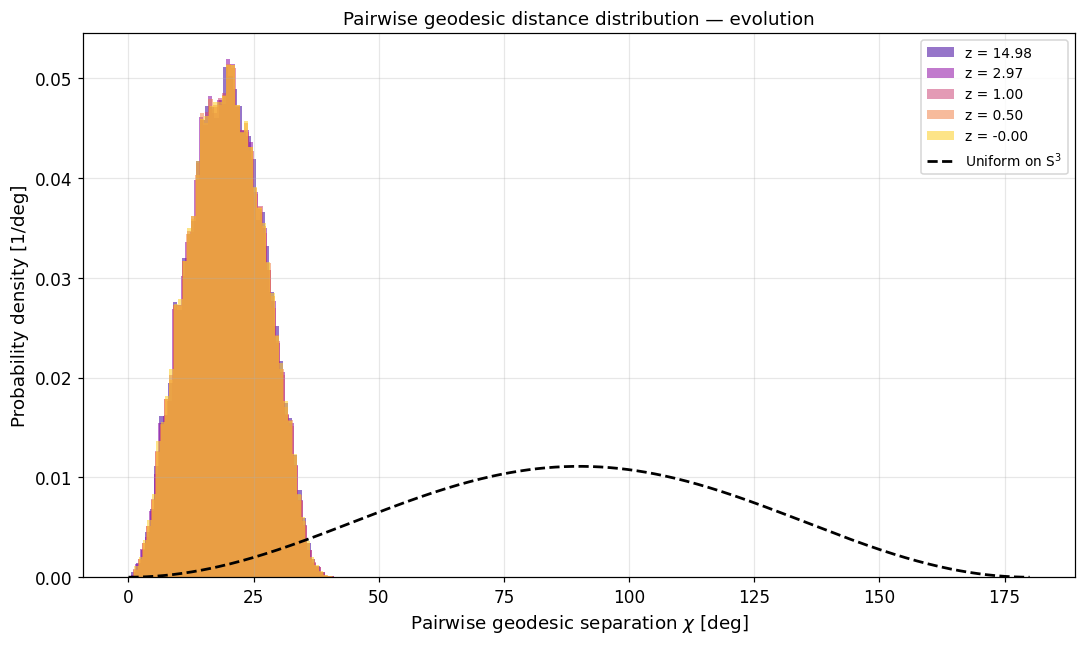

In [12]:
print('Computing pairwise geodesic distances for all valid snapshots...')
fig, ax = plt.subplots(figsize=(10, 6))
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_files)))
plotted = 0

for sf, col in zip(snap_files, colors):
    d   = load_snapshot(sf)
    p   = d['pos']
    if len(p) == 0:
        print(f'  Skipping {sf.name} (all NaN)')
        continue
    z_l = float(d['hdr']['Redshift'])
    Rc  = float(d['hdr']['R_curvature_Mpc'])
    q   = cart_to_quat(p, Rc)
    chi_p = np.degrees(pairwise_chi(q))
    ax.hist(chi_p, bins=45, density=True, alpha=0.55, color=col, label=f'z = {z_l:.2f}')
    print(f'  z = {z_l:.3f}: {len(p)} particles, '
          f'median chi = {np.median(chi_p):.2f} deg')
    plotted += 1

if plotted == 0:
    warn_plot(ax, 'No valid snapshots\n(all positions are NaN)')
else:
    chi_ref = np.linspace(0, 180, 400)
    p_ref   = np.sin(np.radians(chi_ref))**2
    p_ref  /= np.trapz(p_ref, chi_ref)
    ax.plot(chi_ref, p_ref, 'k--', lw=1.8, label='Uniform on S$^3$')
    ax.set_xlabel(r'Pairwise geodesic separation $\chi$ [deg]')
    ax.set_ylabel('Probability density [1/deg]')
    ax.set_title('Pairwise geodesic distance distribution — evolution')
    ax.legend(fontsize=9);  ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Two-Point Correlation Function on S³

The **angular two-point correlation function**:
$$\\xi(\\chi) = \\frac{\\hat{p}(\\chi)}{p_{\\rm uniform}(\\chi)} - 1$$
is positive where clustering exceeds the Poisson expectation and negative in voids.

/tmp/ipykernel_257574/2486970740.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_uni /= np.trapz(p_uni, chi_mid)


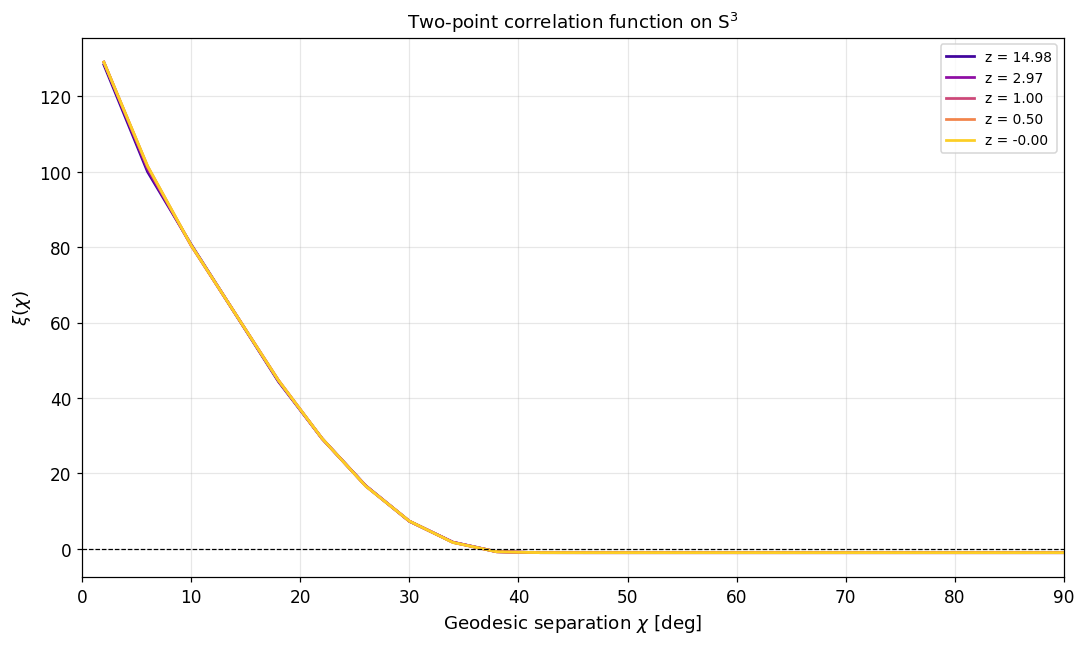

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_files)))
plotted = 0

for sf, col in zip(snap_files, colors):
    d   = load_snapshot(sf)
    p   = d['pos']
    if len(p) == 0:
        continue
    z_l = float(d['hdr']['Redshift'])
    Rc  = float(d['hdr']['R_curvature_Mpc'])
    q   = cart_to_quat(p, Rc)
    chi_p = np.degrees(pairwise_chi(q))

    bins = np.linspace(0, 180, 46)
    cnt, edges = np.histogram(chi_p, bins=bins, density=True)
    chi_mid = 0.5 * (edges[:-1] + edges[1:])
    p_uni = np.sin(np.radians(chi_mid))**2
    p_uni /= np.trapz(p_uni, chi_mid)
    xi = cnt / (p_uni + 1e-30) - 1.0
    ax.plot(chi_mid, xi, color=col, lw=1.8, label=f'z = {z_l:.2f}')
    plotted += 1

if plotted == 0:
    warn_plot(ax, 'No valid snapshots\n(all positions are NaN)')
else:
    ax.axhline(0, c='k', ls='--', lw=0.8)
    ax.set_xlabel(r'Geodesic separation $\chi$ [deg]')
    ax.set_ylabel(r'$\xi(\chi)$')
    ax.set_title('Two-point correlation function on S$^3$')
    ax.set_xlim(0, 90);  ax.legend(fontsize=9);  ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()